In [1]:
import sys
sys.path.append("../ext/equi-rl-for-pomdps")
from rgbd_sym.api import make_env
import argparse
import numpy as np
from rgbd_sym.tool.plt import use_backend, plot_img, plot_traj
import matplotlib.pyplot as plt
from rgbd_sym.tool.sym import local_sym_step, get_sym_params, generate_sym2, actions2Ts
from rgbd_sym.tool.depth import get_intrinsic_matrix, projection_matrix_to_K
import time
from copy import deepcopy

size = 84




Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
env, env_config = make_env(tags=['block_pull'], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
print("K", K)

args = get_sym_params('block_pull')
args['K'] = K
# generate ground truth trajectory

for k, v in args.items():
    print(f"{k}: {v}")




pybullet build time: Nov 28 2023 23:52:03


robot id None
K [[59.98221231  0.         42.        ]
 [ 0.         59.98221231 42.        ]
 [ 0.          0.          1.        ]]
action_delta_pos: 0.05
action_delta_rot: 0.39269908169872414
pc_x_center: 0.0
pc_y_center: 0.0
pc_z_center: 0.75
pc_range: 0.8
voxel_res: 84
depth_real_min: 0
depth_real_max: 1
depth_upsample: 6
out_image_type: depth
out_background_encoding: 255
traj_nums: 4
radius_ratio: 0.994654585558191
height_ratio: 0.9497896410541808
screw_angle: 4.6147936225293185
sym_z_distance_thres: -0.086
K: [[59.98221231  0.         42.        ]
 [ 0.         59.98221231 42.        ]
 [ 0.          0.          1.        ]]


/home/ben/miniconda3/envs/rgbd-sym/lib/python3.9/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [41]:
from matplotlib.pyplot import imshow, subplot, axis, cm, show
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

def plot_traj(
    point_mats,
    elev=45,
    azim=45,
    roll=45,
    no_grid=False,
    point_min = None,
    point_max = None,
    no_legend=False,
    no_tick=False,
):
    fig = plt.figure()
    ax = plt.axes(projection="3d")
    # ax.axes.set_xlim3d(left=range_min[0], right=range_max[0])
    # ax.axes.set_ylim3d(bottom=range_min[1], top=range_max[1])
    # ax.axes.set_zlim3d(bottom=range_min[2], top=range_max[2])
    
    if not no_grid:
        ax.set_xlabel("$X$")
        ax.set_ylabel("$Y$")
        ax.set_zlabel("$Z$")
    # if legend_txt == None:
    pc_min = point_min
    pc_max = point_max
    for point_mat in point_mats:
        pc = point_mat['mat']
        args = point_mat.copy()
        args.pop('mat', None)
        ax.plot3D(
            pc[:, 0].tolist(),
            pc[:, 1].tolist(),
            pc[:, 2].tolist(),
            **args,
        )
        _min = np.min(pc, axis=0)
        _max = np.max(pc, axis=0)
        pc_min = _min if pc_min is None else np.minimum(pc_min, _min)
        pc_max = _max if pc_max is None else np.maximum(pc_max, _max)
    _range = np.max(pc_max- pc_min)

    if not no_legend:
        plt.legend(loc="best")
    ax.view_init(elev=elev, azim=azim, roll=roll)
    ax.axes.set_xlim3d(left=pc_min[0], right=pc_min[0]+_range)
    ax.axes.set_ylim3d(bottom=pc_min[1], top=pc_min[1]+_range)
    ax.axes.set_zlim3d(bottom=pc_min[2], top=pc_min[2]+_range)
    if no_grid:
        ax.grid(False)
    if no_tick:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])
        ax.xaxis.line.set_color('w')
        ax.yaxis.line.set_color('w')
        ax.zaxis.line.set_color('w')
    show()


robot id None


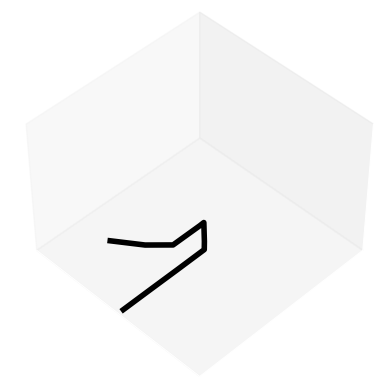

In [42]:
env, env_config = make_env(tags=['block_pull'], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
args = get_sym_params('block_pull')
args['K'] = K
origin_actions = []
obss_origin = [obs]
done = False
while not done:
    action = env.pull_movable()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    obss_origin.append(obs)

points_mats = []
trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
pc_mat = {}
pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat["linewidth"] = 4
pc_mat["alpha"] = 1
pc_mat["label"] = f"original traj"
pc_mat["color"] = "k"
points_mats.append(pc_mat)

# radius_ratios = [0.5,0.8,1.5,2]
# colors = ['b','g','r','c','m','y']
# for traj_i, var in enumerate(radius_ratios):
#     args['traj_nums'] = 60
#     args['radius_ratio'] = var
#     args['height_ratio'] = 1
#     args['screw_angle'] = 0
#     new_obss, new_actionss = generate_sym2(obss_origin, origin_actions, 
#                 **args)



#     for i, new_actions in enumerate(new_actionss):
#         new_trajTs = actions2Ts(
#         [-a for a in reversed(new_actions)],
#         action_delta_pos=args["action_delta_pos"],
#         action_delta_rot=args["action_delta_rot"],
#         )
#         pc_mat = {}
#         pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in new_trajTs])
#         pc_mat["linewidth"] = 1
#         pc_mat["color"] = colors[traj_i]
#         pc_mat["alpha"] = 0.3
#         if i == 0:
#             pc_mat["label"] = f"radius {var}"
#         points_mats.append(pc_mat)   

plot_traj(points_mats, elev=45, azim=135, roll=0, no_grid=True, point_min=[-0.15,-0.3,0],
          point_max=[0.15,0.0,0.3],no_legend=True,no_tick=True)

robot id None


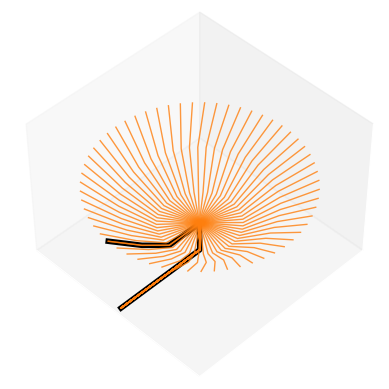

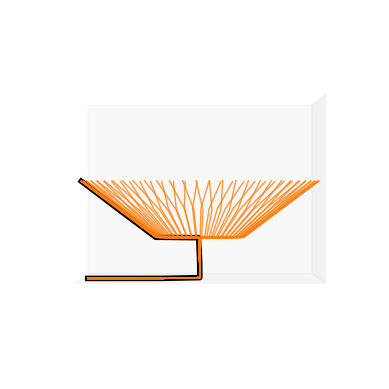

In [71]:
env, env_config = make_env(tags=['block_pull'], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
args = get_sym_params('block_pull')
args['K'] = K
origin_actions = []
obss_origin = [obs]
done = False
while not done:
    action = env.pull_movable()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    obss_origin.append(obs)

points_mats = []
trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
pc_mat = {}
pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat["linewidth"] = 4
pc_mat["alpha"] = 1
pc_mat["label"] = f"original traj"
pc_mat["color"] = "k"
points_mats.append(pc_mat)

vars = [1]
colors = ['tab:orange','g','r','c','m','y']
for traj_i, var in enumerate(vars):
    args['traj_nums'] = 60
    args['radius_ratio'] = 1
    args['height_ratio'] = var
    args['screw_angle'] = 0
    new_obss, new_actionss = generate_sym2(obss_origin, origin_actions, 
                **args)



    for i, new_actions in enumerate(new_actionss):
        new_trajTs = actions2Ts(
        [-a for a in reversed(new_actions)],
        action_delta_pos=args["action_delta_pos"],
        action_delta_rot=args["action_delta_rot"],
        )
        pc_mat = {}
        pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in new_trajTs])
        pc_mat["linewidth"] = 1
        pc_mat["color"] = colors[traj_i]
        pc_mat["alpha"] = 0.8
        if i == 0:
            pc_mat["label"] = f"height {var}"
        points_mats.append(pc_mat)   

plot_traj(points_mats, elev=45, azim=135, roll=0, no_grid=True, point_min=[-0.15,-0.3,0],
          point_max=[0.15,0.0,0.3],no_legend=True,no_tick=True)
plot_traj(points_mats,  elev=0, azim=180, roll=0, no_grid=True, point_min=[-0.15,-0.3,0],
          point_max=[0.15,0.0,0.3],no_legend=True,no_tick=True)

robot id None


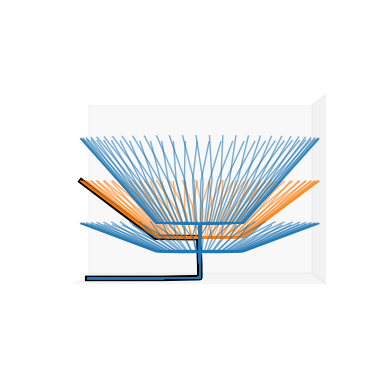

In [70]:
env, env_config = make_env(tags=['block_pull'], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
args = get_sym_params('block_pull')
args['K'] = K
origin_actions = []
obss_origin = [obs]
done = False
while not done:
    action = env.pull_movable()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    obss_origin.append(obs)

points_mats = []
trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
pc_mat = {}
pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat["linewidth"] = 4
pc_mat["alpha"] = 1
pc_mat["label"] = f"original traj"
pc_mat["color"] = "k"
points_mats.append(pc_mat)

vars = [1, 0.5,1.5]
colors = ['tab:orange','tab:blue','tab:blue','tab:blue','tab:blue','tab:blue','y']
for traj_i, var in enumerate(vars):
    args['traj_nums'] = 60
    args['radius_ratio'] = 1
    args['height_ratio'] = var
    args['screw_angle'] = 0
    new_obss, new_actionss = generate_sym2(obss_origin, origin_actions, 
                **args)



    for i, new_actions in enumerate(new_actionss):
        new_trajTs = actions2Ts(
        [-a for a in reversed(new_actions)],
        action_delta_pos=args["action_delta_pos"],
        action_delta_rot=args["action_delta_rot"],
        )
        pc_mat = {}
        pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in new_trajTs])
        pc_mat["linewidth"] = 1
        pc_mat["color"] = colors[traj_i]
        pc_mat["alpha"] = 0.6
        if i == 0:
            pc_mat["label"] = f"height {var}"
        points_mats.append(pc_mat)   

plot_traj(points_mats, elev=0, azim=180, roll=0,no_grid=True, point_min=[-0.15,-0.3,0],
          point_max=[0.15,0.0,0.3],no_legend=True,no_tick=True)

robot id None


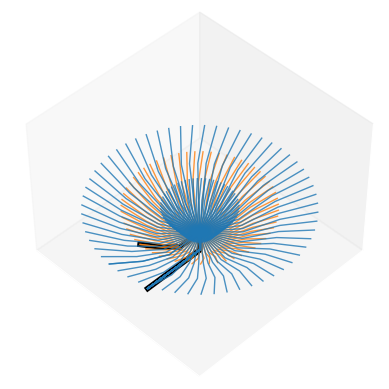

In [68]:
env, env_config = make_env(tags=['block_pull'], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
args = get_sym_params('block_pull')
args['K'] = K
origin_actions = []
obss_origin = [obs]
done = False
while not done:
    action = env.pull_movable()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    obss_origin.append(obs)

points_mats = []
trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
pc_mat = {}
pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat["linewidth"] = 4
pc_mat["alpha"] = 1
pc_mat["label"] = f"original traj"
pc_mat["color"] = "k"
points_mats.append(pc_mat)

vars = [1, 0.5,1.5]
colors = ['tab:orange','tab:blue','tab:blue','tab:blue','tab:blue','tab:blue','y']
for traj_i, var in enumerate(vars):
    args['traj_nums'] = 60
    args['radius_ratio'] = var
    args['height_ratio'] = 1
    args['screw_angle'] = 0
    new_obss, new_actionss = generate_sym2(obss_origin, origin_actions, 
                **args)



    for i, new_actions in enumerate(new_actionss):
        new_trajTs = actions2Ts(
        [-a for a in reversed(new_actions)],
        action_delta_pos=args["action_delta_pos"],
        action_delta_rot=args["action_delta_rot"],
        )
        pc_mat = {}
        pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in new_trajTs])
        pc_mat["linewidth"] = 1
        pc_mat["color"] = colors[traj_i]
        pc_mat["alpha"] = 0.8
        if i == 0:
            pc_mat["label"] = f"radius {var} with scree {args['screw_angle']} Deg"
        points_mats.append(pc_mat)   

plot_traj(points_mats, elev=45, azim=135, roll=0, no_grid=True, point_min=[-0.15,-0.3,0],
          point_max=[0.15,0.0,0.3],no_legend=True,no_tick=True)

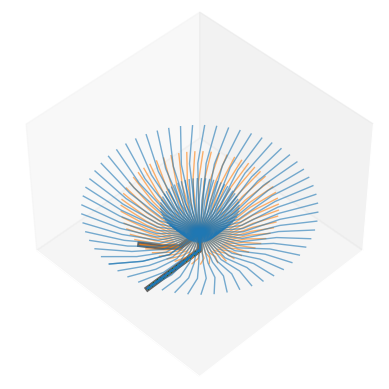

In [69]:
for p in points_mats:
    p["alpha"] = 0.6
plot_traj(points_mats, elev=45, azim=135, roll=0, no_grid=True, point_min=[-0.15,-0.3,0],
          point_max=[0.15,0.0,0.3],no_legend=True,no_tick=True)

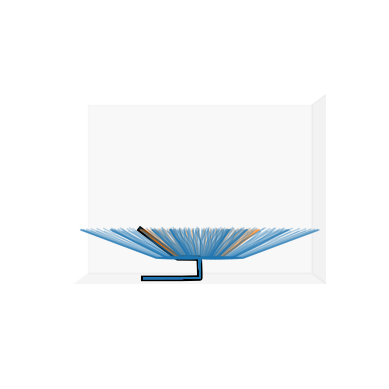

In [56]:
plot_traj(points_mats, elev=0, azim=180, roll=0,no_grid=True, point_min=[-0.15,-0.3,0],
          point_max=[0.15,0.0,0.3],no_legend=True,no_tick=True)

robot id None


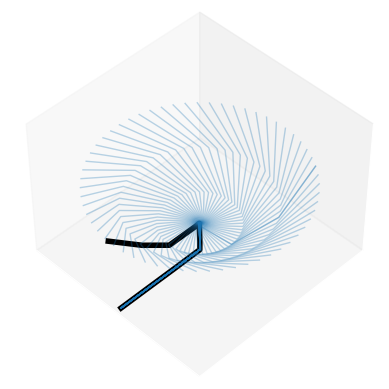

In [60]:
env, env_config = make_env(tags=['block_pull'], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
args = get_sym_params('block_pull')
args['K'] = K
origin_actions = []
obss_origin = [obs]
done = False
while not done:
    action = env.pull_movable()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    obss_origin.append(obs)

points_mats = []
trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
pc_mat = {}
pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat["linewidth"] = 4
pc_mat["alpha"] = 1
pc_mat["label"] = f"original traj"
pc_mat["color"] = "k"
points_mats.append(pc_mat)

vars = [1]
colors = ['tab:blue','tab:blue','tab:blue','tab:blue','tab:blue','y']
for traj_i, var in enumerate(vars):
    args['traj_nums'] = 60
    args['radius_ratio'] = var
    args['height_ratio'] = 1
    # if traj_i == 0:
    #     args['screw_angle'] = 0
    # else:
    args['screw_angle'] = 30
    new_obss, new_actionss = generate_sym2(obss_origin, origin_actions, 
                **args)



    for i, new_actions in enumerate(new_actionss):
        new_trajTs = actions2Ts(
        [-a for a in reversed(new_actions)],
        action_delta_pos=args["action_delta_pos"],
        action_delta_rot=args["action_delta_rot"],
        )
        pc_mat = {}
        pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in new_trajTs])
        pc_mat["linewidth"] = 1
        pc_mat["color"] = colors[traj_i]
        pc_mat["alpha"] = 0.3
        if i == 0:
            pc_mat["label"] = f"radius {var} with scree {args['screw_angle']} Deg"
        points_mats.append(pc_mat)   

plot_traj(points_mats, elev=45, azim=135, roll=0, no_grid=True, point_min=[-0.15,-0.3,0],
          point_max=[0.15,0.0,0.3],no_legend=True,no_tick=True)

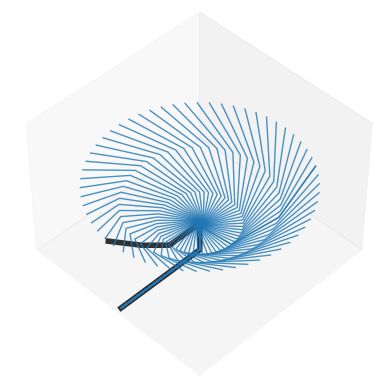

In [65]:
for p in points_mats:
    p["alpha"] = 0.8
plot_traj(points_mats, elev=45, azim=135, roll=0, no_grid=True, point_min=[-0.15,-0.3,0],
          point_max=[0.15,0.0,0.3],no_legend=True,no_tick=True)